# Step 2 — Dataset Loading & FFT Preprocessing
Run each cell top to bottom. By the end you will have:
- A working DataLoader producing `(spatial, freq, label)` batches
- Visual confirmation of what both branches 'see'
- A reusable `dataset.py` module ready for real data

## 2.1 Imports & path setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml

from dataset import (
    DummyDeepfakeDataset,
    DeepfakeDataset,
    get_dataloaders,
    compute_fft,
    build_samples,
    split_samples,
)

# Load config
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print('Imports OK')

d:\cpe646-deepfake\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
Imports OK


## 2.2 Create dummy dataset & inspect a single sample

In [2]:
ds = DummyDeepfakeDataset(num_samples=100, split='train')
sample = ds[0]

print(f"spatial shape : {sample['spatial'].shape}   (C, H, W)")
print(f"freq shape    : {sample['freq'].shape}   (1, H, W)")
print(f"label         : {sample['label']} ({'fake' if sample['label'] == 1 else 'real'})")
print(f"spatial range : [{sample['spatial'].min():.3f}, {sample['spatial'].max():.3f}]")
print(f"freq range    : [{sample['freq'].min():.3f}, {sample['freq'].max():.3f}]")

spatial shape : torch.Size([3, 224, 224])   (C, H, W)
freq shape    : torch.Size([1, 224, 224])   (1, H, W)
label         : 0 (real)
spatial range : [-0.440, 1.037]
freq range    : [0.000, 1.000]


## 2.3 Visualize spatial vs frequency view — real vs fake

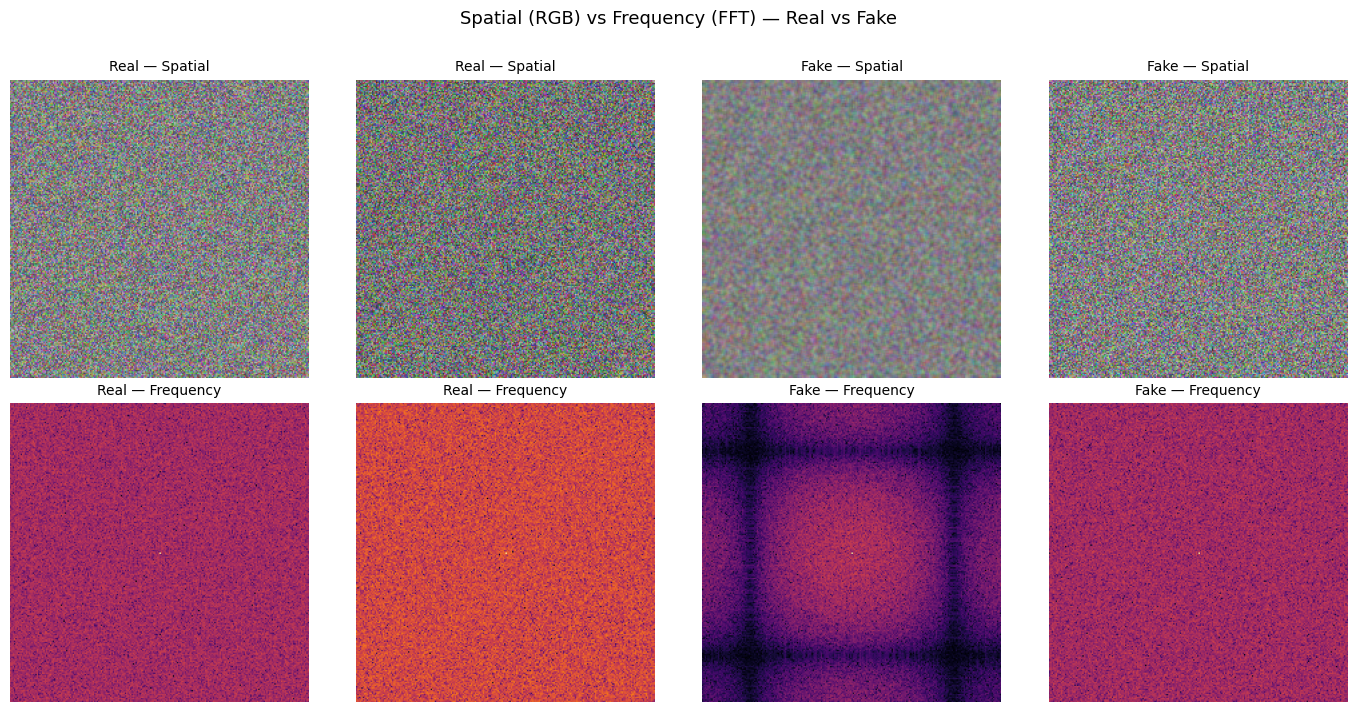

Figure saved to results/figures/spatial_vs_freq.png


In [3]:
# Collect 2 real and 2 fake samples
reals, fakes = [], []
for i in range(len(ds)):
    s = ds[i]
    if s['label'] == 0 and len(reals) < 2: reals.append(s)
    if s['label'] == 1 and len(fakes) < 2: fakes.append(s)
    if len(reals) == 2 and len(fakes) == 2: break

samples_to_show = reals + fakes
titles = ['Real', 'Real', 'Fake', 'Fake']

# Helper: de-normalize spatial image for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def to_display(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Spatial (RGB) vs Frequency (FFT) — Real vs Fake', fontsize=13, y=1.01)

for col, (s, title) in enumerate(zip(samples_to_show, titles)):
    # Row 0: spatial RGB
    axes[0, col].imshow(to_display(s['spatial']))
    axes[0, col].set_title(f'{title} — Spatial', fontsize=10)
    axes[0, col].axis('off')
    # Row 1: FFT magnitude
    axes[1, col].imshow(s['freq'].squeeze().numpy(), cmap='inferno')
    axes[1, col].set_title(f'{title} — Frequency', fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/spatial_vs_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to results/figures/spatial_vs_freq.png')

## 2.4 Build DataLoaders & inspect a full batch

In [4]:
# use_dummy=True while real data downloads
# Switch to use_dummy=False once data/dfdc/ and data/faceforensics/ are populated
train_loader, val_loader, test_loader = get_dataloaders(cfg, use_dummy=True)

# Grab one batch
batch = next(iter(train_loader))

print('Batch contents:')
print(f"  spatial : {batch['spatial'].shape}   dtype={batch['spatial'].dtype}")
print(f"  freq    : {batch['freq'].shape}   dtype={batch['freq'].dtype}")
print(f"  labels  : {batch['label']}")
print(f"  paths   : {batch['path'][:2]} ...")

  [DataLoader] Using DUMMY synthetic dataset
  [DataLoader] Train: 320 | Val: 80 | Test: 80
Batch contents:
  spatial : torch.Size([32, 3, 224, 224])   dtype=torch.float32
  freq    : torch.Size([32, 1, 224, 224])   dtype=torch.float32
  labels  : tensor([1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 0, 0])
  paths   : ['dummy_246.jpg', 'dummy_259.jpg'] ...


## 2.5 Move batch to GPU & confirm

In [5]:
spatial = batch['spatial'].to(device)
freq    = batch['freq'].to(device)
labels  = batch['label'].to(device)

print(f'spatial on : {spatial.device}')
print(f'freq on    : {freq.device}')
print(f'labels on  : {labels.device}')

# Check VRAM usage
if device.type == 'cuda':
    alloc = torch.cuda.memory_allocated() / 1024**2
    print(f'VRAM used  : {alloc:.1f} MB')

spatial on : cuda:0
freq on    : cuda:0
labels on  : cuda:0
VRAM used  : 24.5 MB


## 2.6 Class balance check

Dataset size : 100
Real (0)     : 48 (48.0%)
Fake (1)     : 52 (52.0%)


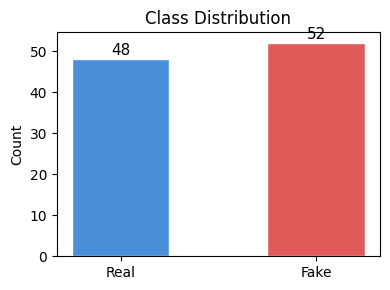

In [6]:
all_labels = [ds[i]['label'].item() for i in range(len(ds))]
reals_count = all_labels.count(0)
fakes_count = all_labels.count(1)
total = len(all_labels)

print(f'Dataset size : {total}')
print(f'Real (0)     : {reals_count} ({100*reals_count/total:.1f}%)')
print(f'Fake (1)     : {fakes_count} ({100*fakes_count/total:.1f}%)')

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Real', 'Fake'], [reals_count, fakes_count],
       color=['#4A90D9', '#E05A5A'], edgecolor='white', width=0.5)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate([reals_count, fakes_count]):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.7 How to switch to real data (run this when downloads finish)
```
data/
  dfdc/
    real/   ← paste real face crops here
    fake/   ← paste fake face crops here
  faceforensics/
    real/
    fake/
```
Then in cell 2.4, change `use_dummy=True` → `use_dummy=False` and re-run.

---
## Step 2 Complete
- `dataset.py` is ready and tested
- DataLoaders produce `(spatial, freq, label)` batches on GPU
- FFT spectra visualized and saved

**Next → Step 3: Spatial Branch (EfficientNet-B0)**